FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS
Objective:  
Leverage ARIMA and Exponential Smoothing techniques to forecast future exchange rates based on historical data provided in the exchange_rate.csv dataset.
Dataset:  
The dataset contains historical exchange rate with each column representing a different currency rate over time. The first column indicates the date, and the second column represents exchange rates USD to Australian Dollar.
Part 1: Data Preparation and Exploration  
1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.  
2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.  
3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.  
Part 2: Model Building - ARIMA  
1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.  
2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.   
3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.  
4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.  
Part 3: Evaluation and Comparison  
1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.  
2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.  
3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.   
Deliverables:  
●	Include visualizations and explanations for the choices and findings at each step.  
●	Well-commented Python code that used to conduct the analysis and build the models.  
Assessment Criteria:  
●	Accuracy and completeness of the data preparation and exploration steps.    
●	Justification for model selection and parameter tuning decisions.  
●	Clarity and depth of the analysis in the diagnostics and model evaluation stages.  
This assignment offers hands-on experience with real-world data, applying sophisticated time series forecasting methods to predict future currency exchange rates.  
  


#SEQUENTIAL MODELS.
1. Time Series analysis/ Forecastin analysis
2. RNN(Recurrent neural network)
3. LSTM (Long short term memory)
3. GRU Gated recurrent unit



### TIME SERIES:
time series data is a sequence of data points collected or recorded at successive points in time  usually at uniform intervaö(such as seconds hours day months or years) where the order of data matters
IN SIMPLE WOPRDS it is a data observed overtime
Time order is essential- the value at one time point depends on previous values.
is used when each and every record is depehndentg on eachg other ex: unit of time
time series concept
visualization
Model building methodlogy isong ARIMA

there are two kinds of analysis in Time series univariant(only on feature) and multivariant(multipole features)
the data above looks like univariant

key charachterestics
temporal order: dta is arrange chrinologically  
time dependency: observations are often correlated with their past values  
frequency: can be hourly daily weekly monthly yearly etc  

there are 4 terms related to time series  

1. Trend: either upward or downward pattern. meaning long term movement.
shows persistent upward or downward movement over time. often caused by structureal factors like population growth, technology, or economic development ex: increasing smartphone adaprion over years. rising global temperaturesc. charachterstics: smooth and gradual. can be lineafr or non linear

2. seasonal: fixed interval pattern : means regular yearly pattern ex: AC, ice cream sales increasing every summer. retail porice peking suring fstivals
occurs due to weather, holidays, or institiútional schedules.
the cycle elngth is usually within one year.

3. cyclical: multi year pattern. meaning long economic cycles ex: cycle
the cyclic component reflects long-term oscillations around the trend.
usually associate with busineess cycles.
duration is longer than one year and not strictly regular.

ex: economic expansion. recession to recovery
housing market booms and busts

4. irregular: unpredictable pattern. meaning random noise ex: gold price, war, pendemic. market xrasg´h after sudden policy changes.
represents unpredictable fluctuations caused by random events.
it doesnot repeat regularly.
it happens due to random events or unexplained factors
it represents small random shocks after accounting for trend and seasonality

In time series we dint do syntax for EDA we use visualization.
line, histo, density, boxplot. we use them to understand the data
most fo the algotithms want stationary data which means variance is constant.
if data is not stationary then you have to convert it into stationary


if data has trend then we need to convert the data in to stationary

ARIMA is the algorithm for that

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/exchange_rate.csv')
df

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


here date is used as index and date never gives analysis/date can never be a feature

In [ ]:
df.shape

(7588, 2)

In [ ]:
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [ ]:
df.tail()

,date,Ex_rate
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825
7587,10-10-2010 00:00,0.720825


In [ ]:
df.info() #here it shows date as also object so we need to add it to date type. if the numerical column also shows object then you can convert it using below code

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


#df['ex_rate]= pd.to_numeric(df['ex_rate], errors='coerce')
to conver to date and time
#df['date']= pd.to_datetime(df['date'], errors='coerce')
#errors='coerce' means valid numeric strings are converted normally invalid values are replaced with NaN
#pd.to_numeric attempts to convert each value in df['ex_rate] to a number (int or float)

In [ ]:
df.isnull().sum()

,0
date,0
Ex_rate,0


In [ ]:
df.duplicated().sum()

np.int64(0)

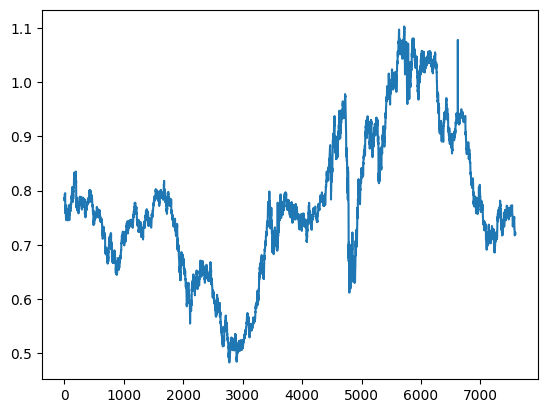

In [ ]:
#line plot
plt.plot(df['Ex_rate']) # plot is line plot by default
plt.show()
# the data is
# when in the graph there is no upward and downward then that is stationary data and no trend. but here its non statuionary data. AARIMA is the algorithm where we need stationary data

The exchange rate series shows fluctuations over time with several upward and downward movements. No obvious seasonal pattern is visible, but trends and volatility can be observed.

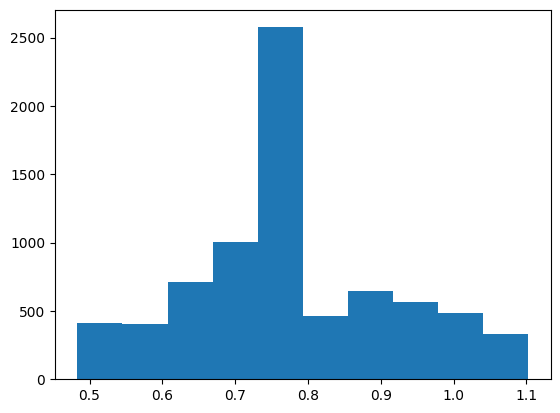

In [ ]:
#histogram
plt.hist(df['Ex_rate'])
plt.show()

<Axes: ylabel='Density'>

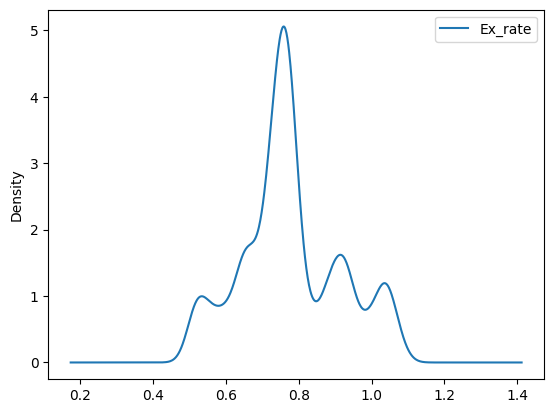

In [ ]:
#density plot
df.plot(kind='kde') #kernel density estimate. it just gives histogram smooth curve

In [ ]:
#need to convert date to date time
df['date']= pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')

#extract year and month
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month
df['day']=df['date'].dt.day
df['hour']=df['date'].dt.hour
df['minute']=df['date'].dt.minute
#THIS FUNCTION MEAN WE ARE ADDING MORE COLUMNS as for analysis we cannot take date

In [ ]:
df.head()

,date,Ex_rate,year,month,day,hour,minute
0,1990-01-01,0.7855,1990,1,1,0,0
1,1990-01-02,0.7818,1990,1,2,0,0
2,1990-01-03,0.7867,1990,1,3,0,0
3,1990-01-04,0.7860,1990,1,4,0,0
4,1990-01-05,0.7849,1990,1,5,0,0


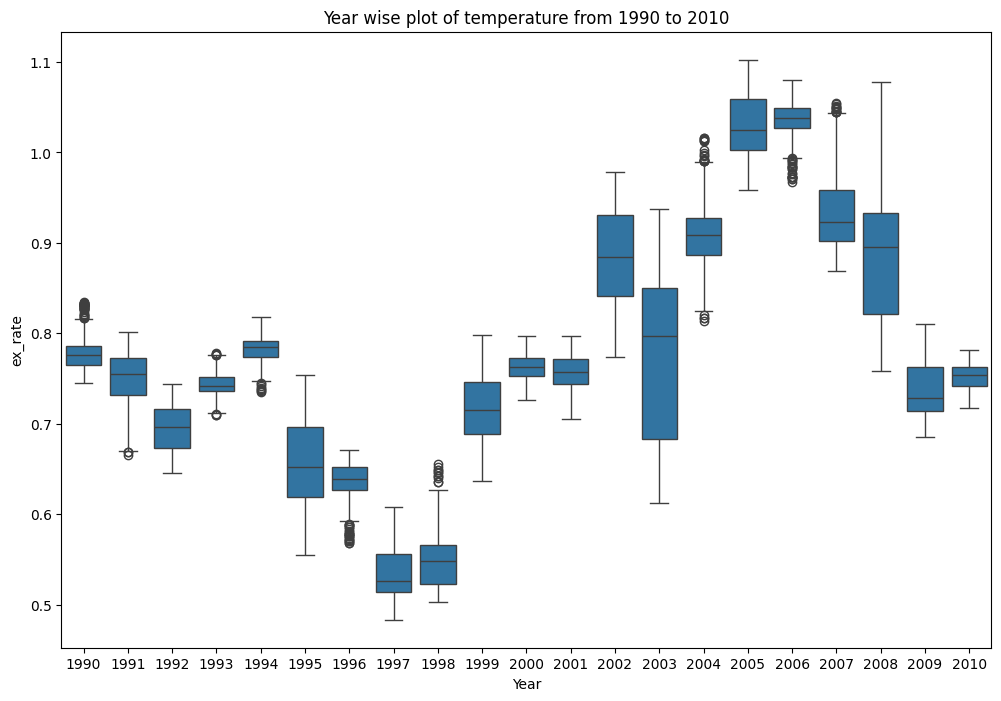

In [ ]:
#create a box plot using seaborn
plt.figure(figsize=(12,8))
sns.boxplot(x='year', y='Ex_rate', data=df)
plt.xlabel('Year')
plt.ylabel('ex_rate')
plt.title('Year wise plot of temperature from 1990 to 2010')
plt.show()
#in 9 years there ar eoutliers

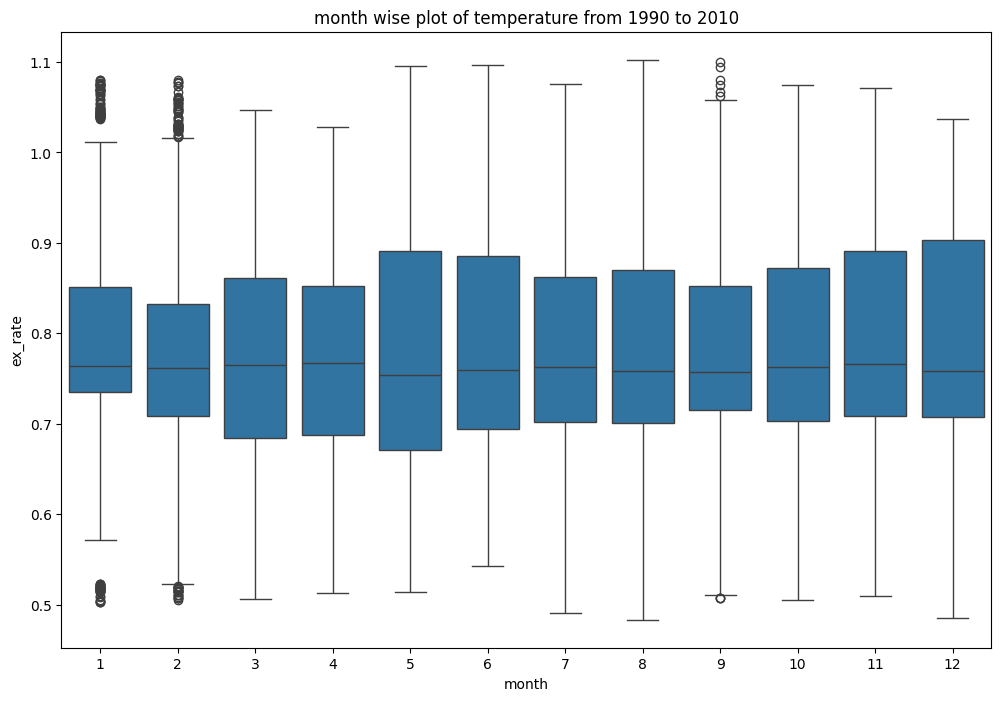

In [ ]:
#create a box plot using seaborn
plt.figure(figsize=(12,8))
sns.boxplot(x='month', y='Ex_rate', data=df)
plt.xlabel('month')
plt.ylabel('ex_rate')
plt.title('month wise plot of temperature from 1990 to 2010') #for which year is it showing
plt.show() #the rusult is clubt months of each year to one and  not just one year
# in 3 months there are outliers

#-----Till here was EDA------

In [ ]:
#RESAMPLING AND INTERPOLATION
# in time series when there is missing data somewhere then you dont take average of whole column but previous and next column
#when there is a small data set we cant train our model we cant do training testing it becomes underfitting so we use up and down sampling
#Resampling involves changing the frequency of your time series observation. two types of resampling  are
#upsampling: where you increase the frequency of samples such as from minutes to seconds. we expand the data
#downsampling: where you decrease the frequency of samples , such as from days to monhts. when dat is more go for downsampling
#DATA transformation is required when our data is non stationary. there are many transforms to choose from and each has a different mathematical intutuin. 1, Square root transform, log transform
#to do that there is one test

#TIME SERIES VISUALIZATION
#in time serires most of the time target is y and the same target is also feature as we are comparing todays value with previous value
#lagplot
#lag1 1 one value previously this becomes x like another feature(yt-1)
#lag2  2 values previously this becomes x like anozher feature(yt-2)

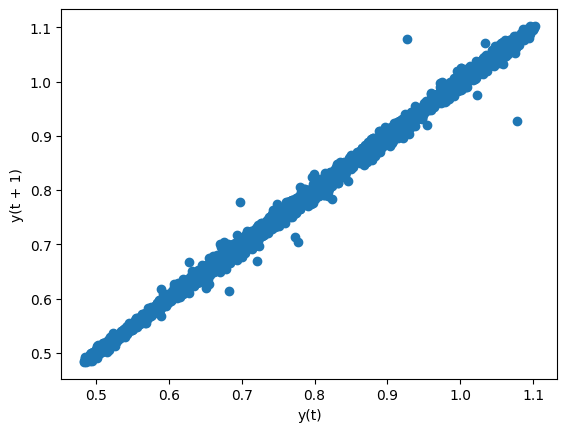

In [ ]:
#lag plot
from pandas.plotting import  lag_plot
lag_plot(df['Ex_rate'])
plt.show()# current data is dependent on next day value because of linear data

<Figure size 4000x1000 with 0 Axes>

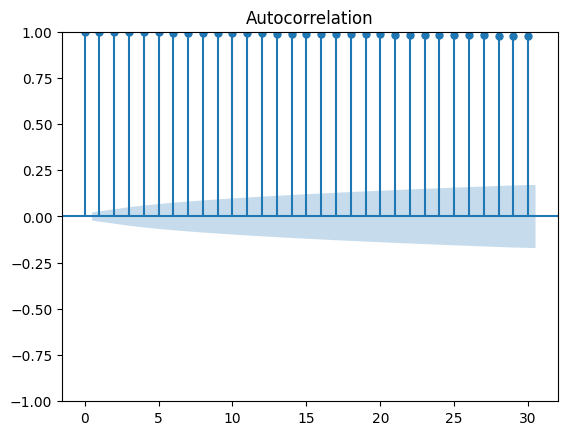

In [ ]:
#cerate an Autocorrelation plot
plt.figure(figsize=(40,10))
from statsmodels.graphics.tsaplots import plot_acf #acf autocorelation function range-1 to +1
plot_acf(df['Ex_rate'],lags=30) #30 values behind
plt.show()
#the values lines are lag 1 lag2...... etc in the below graph only lag1 doesnt come up in the shaded region. lag 2 can also be considered as it doesnt go much into the shaded region

#partitioning is done in sequence
#evaluation metric  is mean absolute deviation or mean squared error or root mean squared error
#AIC: Akaike information criterion. measures model fit but penalizes too many parameters
#'BIC: bayesian information criterion . similar to AIC but penalizes complex models more strongly
#AIC and BIC afre used in Arima model selection to balance model fit and complexity
#ARIMA stands for Auto regressive  integrated moving averagew model. its a combination of 2 model
#to apply arima our data should be sattionary
#different models are AR; MA ARMA; ARIMA
#ARIMA here integrated means differencing
#components of arima:
#autoregressive term: it accounts for relationship bw an on´bservation and its lagged Values
#integrated term :involves differencing the data to make it stationary. differencing is used to remove trends or seasonality in the data.

#differencing this is the process of subtracting the previous observation from the current observation. ex d=1 the model is applied to the differenced series yt-(yt-1)

#moving average term_ thios oart of model uses past forecast errors ina regression like model
#arima p = no of lag observations
#d= is the degree of differencing
# q is the number of lagged forecast erros

#ARIMA MODEL
#steps to build arima model#make the series stationary
if the time series is not stationary apply differencing to remove trends and seasonality
choose the order of the model(p,d,q,)
1. p(AR order): use the partial autocorrelation function(pacf) plot to determin the AR order
2. d(differencing order): determine the number of times to difference the data to make it stationary
3. q (MA order): use the auto correlation function(acf) plot to determine the ma order

fir the model
after selecting the values of p d and q fit the arima model to the data
make predicitons
once the model is fit use it to make future prediciton

In [ ]:
from scipy.stats import zscore

# Calculate Z-scores
df["z_score"] = zscore(df["Ex_rate"])

# Identify anomalies
anomalies = df[abs(df["z_score"]) > 3]

print("Detected Anomalies:")
print(anomalies)

Detected Anomalies:
Empty DataFrame
Columns: [date, Ex_rate, year, month, day, hour, minute, z_score]
Index: []


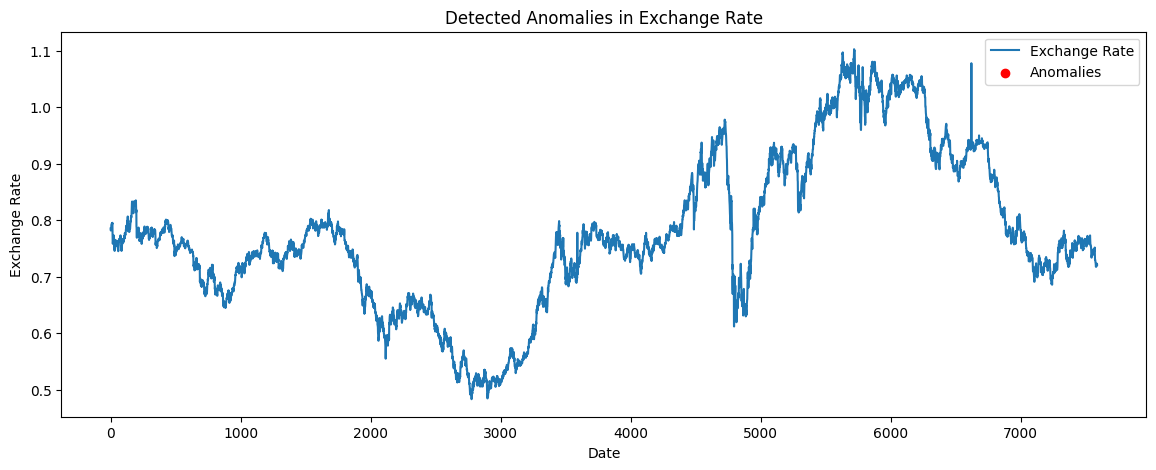

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(df.index, df["Ex_rate"], label="Exchange Rate")

plt.scatter(
    anomalies.index,
    anomalies["Ex_rate"],
    color="red",
    label="Anomalies"
)

plt.title("Detected Anomalies in Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()

plt.show()

In [ ]:
!pip install pmdarima #libraray for time series

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 43.9 MB/s eta 0:00:00


In [ ]:
from statsmodels.tsa.stattools import adfuller  # adfuller checks if data is stationary or non-stationary (Augmented Dickey-Fuller (ADF) test)
from pmdarima import auto_arima  # from auto_arima we will get order of p,d,q
from statsmodels.tsa.arima.model import ARIMA  # ARIMA function for model building
from sklearn.metrics import mean_squared_error
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
df

,date,Ex_rate,year,month,day,hour,minute
0,1990-01-01,0.785500,1990,1,1,0,0
1,1990-01-02,0.781800,1990,1,2,0,0
2,1990-01-03,0.786700,1990,1,3,0,0
3,1990-01-04,0.786000,1990,1,4,0,0
4,1990-01-05,0.784900,1990,1,5,0,0
...,...,...,...,...,...,...,...
7583,2010-10-06,0.718494,2010,10,6,0,0
7584,2010-10-07,0.721839,2010,10,7,0,0
7585,2010-10-08,0.723197,2010,10,8,0,0
7586,2010-10-09,0.720825,2010,10,9,0,0


In [ ]:
#to check data is stationary or not we use adf test as only with graph we cant decide. augmented dikey fuller method
#ADF we have to provide null hypothesis and alternative hypothesis. null hypothesis the time series has a unit root, meaning it is non stationary. alternative hypothesis: the time series does not have a unit root and is stationary
dftest =adfuller(df['Ex_rate'])
print('P value:', dftest[1])
# p value is more than 0.05 so its non stationary
#what to do for stationary?

P value: 0.4492327353597477


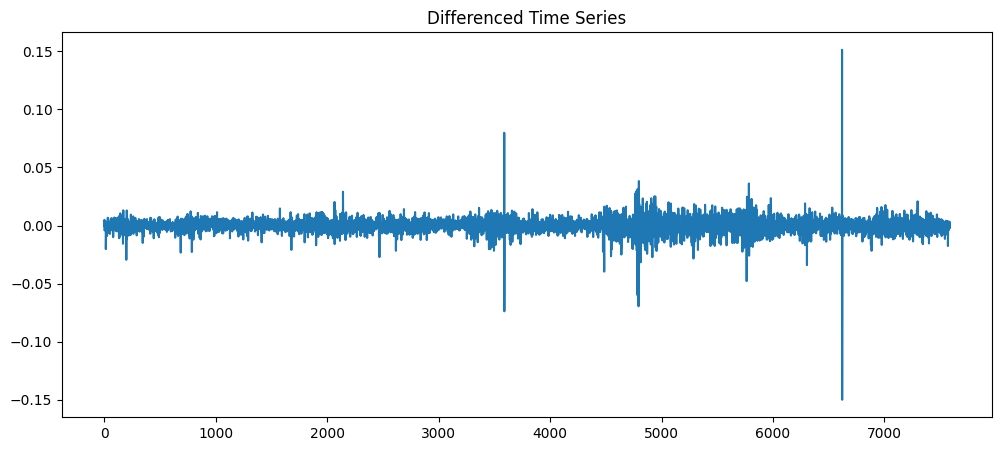

In [ ]:
df_diff = df['Ex_rate'].diff().dropna()
df_diff

plt.figure(figsize=(12,5))
plt.plot(df_diff)
plt.title("Differenced Time Series")
plt.show()

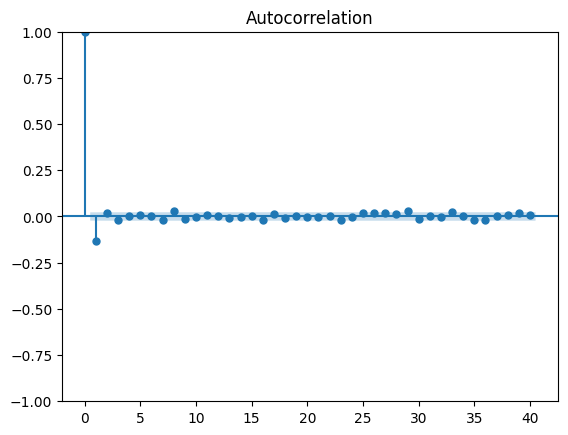

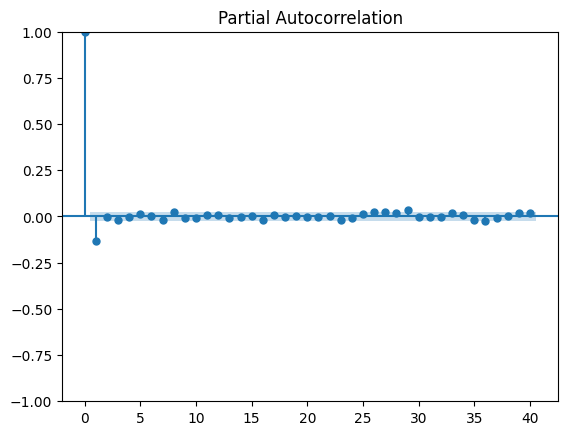

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_diff, lags=40)
plt.show()

plot_pacf(df_diff, lags=40)
plt.show()

The ACF and PACF plots suggest an ARIMA(1,1,0) model because significant spikes are observed at lag 1

In [ ]:
train_size = int(len(df)*0.8)

train = df.iloc[:train_size]

test = df.iloc[train_size:]

In [ ]:
# Find the best ARIMA parameters
stepwise_fit = auto_arima(
    train["Ex_rate"],
    trace=True,
    suppress_warnings=True
)

# Display the selected order
print("Best ARIMA Order:", stepwise_fit.order)

# Build the ARIMA model using the selected order
model = ARIMA(train["Ex_rate"], order=stepwise_fit.order)

# Train the model
model = model.fit()

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-45426.730, Time=6.51 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-45404.538, Time=0.83 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-45424.276, Time=0.41 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-45423.258, Time=1.18 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-45406.255, Time=0.20 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-45428.463, Time=4.24 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-45424.717, Time=3.10 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-45430.403, Time=5.41 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-45398.539, Time=1.10 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-45425.953, Time=0.69 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-45432.092, Time=0.42 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-45424.940, Time=0.31 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-45425.957, Time=0.26 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-45400.258, Time=0.59 sec
 ARIM

In [ ]:
#arima(p,d,q)
#The auto_arima() function was used to identify the most suitable values of (p, d, q) based on the training data. These parameters were then used to build the final ARIMA model, avoiding manual trial and error while improving model selection.

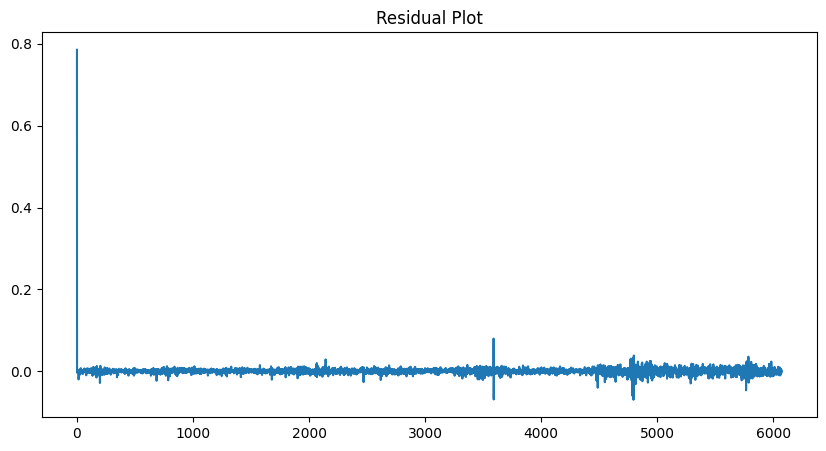

In [ ]:
residuals = model.resid

plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title("Residual Plot")
plt.show()

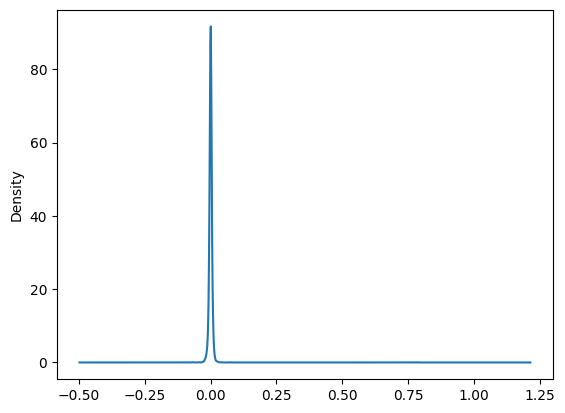

In [ ]:
residuals.plot(kind='kde')
plt.show()
#The residuals fluctuate randomly around zero with no obvious trend, indicating the model adequately captures the data pattern.

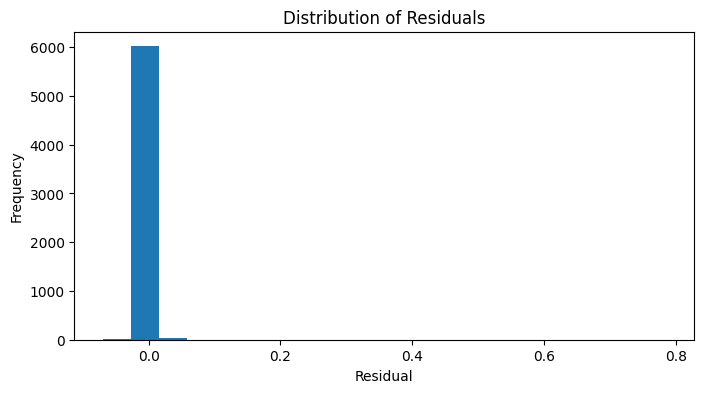

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=20)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

#create ARIMA model can also be done....
#split the data
train = df.iloc[:-30]
test = df.iloc[-30:] #last 30 records for testing purpose
print(train.shape,test.shape)

In [ ]:
arima_forecast = model.forecast(steps=len(test))

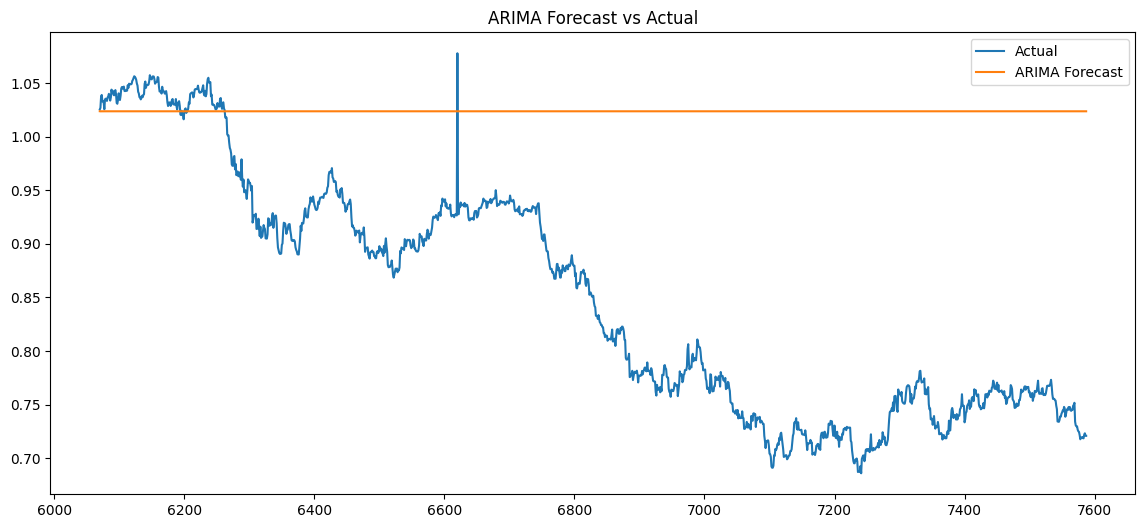

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(test.index,test["Ex_rate"],label="Actual")

plt.plot(test.index,arima_forecast,label="ARIMA Forecast")

plt.title("ARIMA Forecast vs Actual")

plt.legend()

plt.show()

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
ets_model = ExponentialSmoothing(
    train["Ex_rate"],
    trend="add",
    seasonal=None
)

ets_fit = ets_model.fit()

In [ ]:
ets_forecast = ets_fit.forecast(len(test))

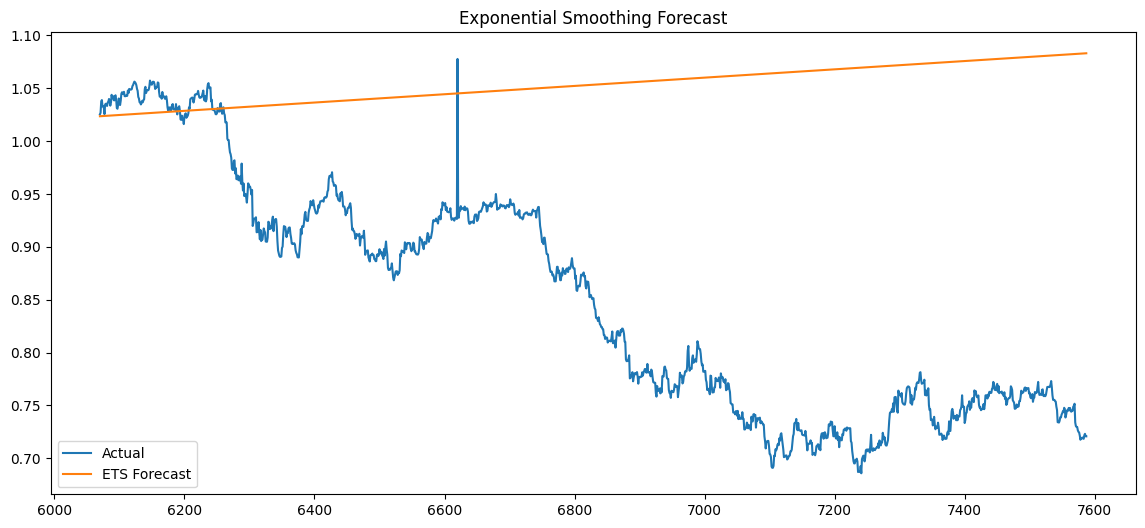

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(test.index,test["Ex_rate"],label="Actual")

plt.plot(test.index,ets_forecast,label="ETS Forecast")

plt.title("Exponential Smoothing Forecast")

plt.legend()

plt.show()

EVALUATION

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae_arima = mean_absolute_error(test["Ex_rate"],arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test["Ex_rate"],arima_forecast))
mape_arima = np.mean(np.abs((test["Ex_rate"]-arima_forecast)/test["Ex_rate"]))*100

In [ ]:
mae_ets = mean_absolute_error(test["Ex_rate"],ets_forecast)
rmse_ets = np.sqrt(mean_squared_error(test["Ex_rate"],ets_forecast))
mape_ets = np.mean(np.abs((test["Ex_rate"]-ets_forecast)/test["Ex_rate"]))*100

In [ ]:
results = pd.DataFrame({
    "Model":["ARIMA","Exponential Smoothing"],
    "MAE":[mae_arima,mae_ets],
    "RMSE":[rmse_arima,rmse_ets],
    "MAPE":[mape_arima,mape_ets]
})

print(results)

                   Model       MAE      RMSE       MAPE
0                  ARIMA  0.177710  0.205437  22.797966
1  Exponential Smoothing  0.206596  0.239104  26.508664


In [ ]:
best_model = results.loc[results["RMSE"].idxmin(),"Model"]
print("Best Performing Model:",best_model)

Best Performing Model: ARIMA


The model with the lowest forecasting errors was selected as the preferred model for predicting future USD/AUD exchange rates.